# Predicting Bank Term-Deposit Subscription

**Student:** Sanaa Arora 
**Student ID:** 26067203
**Subject:** Advanced Data Analytics Algorithms  
**Assessment:** A2 Option 2  
https://github.com/academyquantum85-star/A2_Bank_Marketing

## Research question

Can machine-learning models rank bank customers by their probability
of subscribing to a term deposit using information available before a marketing call?

In [23]:
%pip -q install pandas numpy scikit-learn matplotlib ipywidgets
print("✅ Packages installed")


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ Packages installed


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [25]:
import ssl
import urllib.request
import zipfile
from io import BytesIO

DATA_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

ssl_context = ssl._create_unverified_context()

with urllib.request.urlopen(DATA_URL, context=ssl_context) as response:
    outer_zip_data = response.read()

# Open the outer ZIP file
with zipfile.ZipFile(BytesIO(outer_zip_data)) as outer_zip:
    print("Outer files:", outer_zip.namelist())

    # Read the bank.zip file inside it
    inner_zip_data = outer_zip.read("bank.zip")

# Open the inner bank.zip file
with zipfile.ZipFile(BytesIO(inner_zip_data)) as inner_zip:
    print("Bank files:", inner_zip.namelist())

    # Read the actual CSV file
    with inner_zip.open("bank-full.csv") as file:
        data = pd.read_csv(file, sep=";")

print("Dataset shape:", data.shape)

print("\nFirst five rows:")
display(data.head())

print("\nSubscription counts:")
print(data["y"].value_counts())

Outer files: ['bank.zip', 'bank-additional.zip']
Bank files: ['bank-full.csv', 'bank-names.txt', 'bank.csv']
Dataset shape: (45211, 17)

First five rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Subscription counts:
y
no     39922
yes     5289
Name: count, dtype: int64


In [26]:
FEATURES = [
    "age", "job", "marital", "education", "default",
    "balance", "housing", "loan", "pdays",
    "previous", "poutcome"
]

TARGET = "y"

X = data[FEATURES].copy()
y = (data[TARGET] == "yes").astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 11)
y shape: (45211,)


In [27]:
print("duration" in FEATURES)

False


In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))
print("Test rows:", len(X_test))

Training rows: 31647
Validation rows: 6782
Test rows: 6782


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC_FEATURES = ["age", "balance", "pdays", "previous"]

CATEGORICAL_FEATURES = [
    "job", "marital", "education", "default",
    "housing", "loan", "poutcome"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUMERIC_FEATURES),
    ("categorical", categorical_pipeline, CATEGORICAL_FEATURES)
])

In [31]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

In [32]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_valid)

print("Baseline prediction:", baseline_predictions[0])

Baseline prediction: 0


In [33]:
logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_valid)
logistic_probabilities = logistic_pipeline.predict_proba(X_valid)[:, 1]

print("First five predictions:", logistic_predictions[:5])
print("First five probabilities:", logistic_probabilities[:5])

First five predictions: [0 0 0 0 0]
First five probabilities: [0.09907493 0.1399007  0.1016972  0.07317451 0.04083633]


In [34]:
forest_pipeline.fit(X_train, y_train)

forest_predictions = forest_pipeline.predict(X_valid)
forest_probabilities = forest_pipeline.predict_proba(X_valid)[:, 1]

print("First five predictions:", forest_predictions[:5])
print("First five probabilities:", forest_probabilities[:5])

First five predictions: [0 0 0 0 0]
First five probabilities: [0.05       0.29       0.13666667 0.17666667 0.11666667]


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)

models = {
    "Baseline": baseline,
    "Logistic Regression": logistic_pipeline,
    "Random Forest": forest_pipeline
}

validation_rows = []

for name, model in models.items():
    predictions = model.predict(X_valid)
    probabilities = model.predict_proba(X_valid)[:, 1]

    validation_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, predictions),
        "Precision": precision_score(y_valid, predictions, zero_division=0),
        "Recall": recall_score(y_valid, predictions, zero_division=0),
        "F1": f1_score(y_valid, predictions, zero_division=0),
        "Average Precision": average_precision_score(y_valid, probabilities),
        "ROC-AUC": roc_auc_score(y_valid, probabilities)
    })

validation_results = pd.DataFrame(validation_rows).set_index("Model")
display(validation_results.round(3))

selected_name = validation_results["Average Precision"].idxmax()
selected_model = models[selected_name]

print("Selected model:", selected_name)

,Accuracy,Precision,Recall,F1,Average Precision,ROC-AUC
Model,,,,,,
Baseline,0.883,0.000,0.000,0.000,0.117,0.500
Logistic Regression,0.894,0.675,0.175,0.278,0.348,0.715
Random Forest,0.829,0.300,0.344,0.320,0.256,0.680


Selected model: Logistic Regression


In [36]:
validation_probabilities = selected_model.predict_proba(X_valid)[:, 1]

candidate_thresholds = np.linspace(0.05, 0.95, 37)
threshold_scores = []

for threshold in candidate_thresholds:
    predictions = (validation_probabilities >= threshold).astype(int)
    score = f1_score(y_valid, predictions, zero_division=0)
    threshold_scores.append((float(threshold), score))

best_threshold, best_valid_f1 = max(
    threshold_scores,
    key=lambda result: result[1]
)

print("Selected model:", selected_name)
print("Chosen threshold:", round(best_threshold, 3))
print("Validation F1:", round(best_valid_f1, 3))

Selected model: Logistic Regression
Chosen threshold: 0.2
Validation F1: 0.36


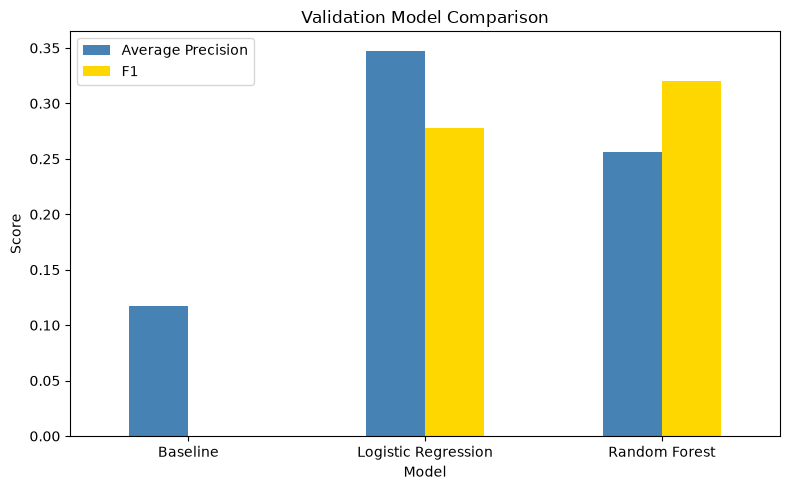

In [37]:
validation_results[["Average Precision", "F1"]].plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "gold"]
)

plt.title("Validation Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
test_probabilities = selected_model.predict_proba(X_test)[:, 1]
test_rows = []

for threshold in [0.50, best_threshold]:
    predictions = (test_probabilities >= threshold).astype(int)

    test_rows.append({
        "Threshold": round(float(threshold), 3),
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0)
    })

test_results = pd.DataFrame(test_rows)
display(test_results.round(3))

print(
    "Test Average Precision:",
    round(average_precision_score(y_test, test_probabilities), 3)
)
print(
    "Test ROC-AUC:",
    round(roc_auc_score(y_test, test_probabilities), 3)
)

test_predictions = (test_probabilities >= best_threshold).astype(int)

,Threshold,Accuracy,Precision,Recall,F1
0,0.5,0.895,0.729,0.166,0.271
1,0.2,0.875,0.448,0.306,0.364


Test Average Precision: 0.365
Test ROC-AUC: 0.729


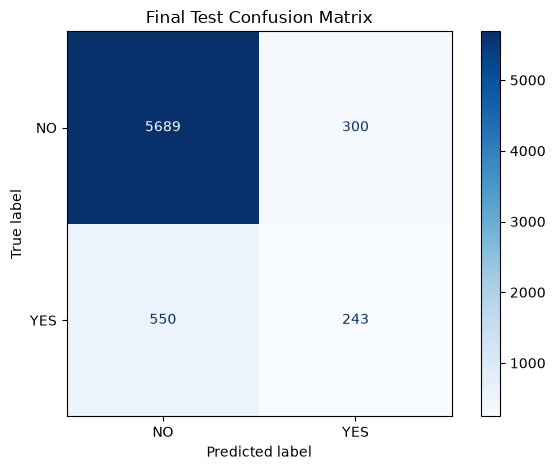

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["NO", "YES"],
    cmap="Blues"
)

plt.title("Final Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, test_predictions, labels=[0, 1])

print("Rows = what really happened; columns = what the model predicted")
print(matrix)
print("Total customers:", matrix.sum())

correct_no, wrong_yes, missed_yes, correct_yes = matrix.ravel()

print("Correctly said NO:", correct_no)
print("Said YES, but customer said NO:", wrong_yes)
print("Said NO, but customer said YES:", missed_yes)
print("Correctly said YES:", correct_yes)

Rows = what really happened; columns = what the model predicted
[[5689  300]
 [ 550  243]]
Total customers: 6782
Correctly said NO: 5689
Said YES, but customer said NO: 300
Said NO, but customer said YES: 550
Correctly said YES: 243


In [41]:
def top_customer_metrics(y_true, probabilities, fraction):
    y_array = np.asarray(y_true)

    number_to_call = int(
        np.ceil(len(y_array) * fraction)
    )

    highest_probability_positions = np.argsort(
        probabilities
    )[::-1][:number_to_call]

    selected_customers = y_array[
        highest_probability_positions
    ]

    subscribers_found = int(
        selected_customers.sum()
    )

    precision_at_capacity = (
        subscribers_found / number_to_call
    )

    recall_at_capacity = (
        subscribers_found / y_array.sum()
    )

    normal_subscription_rate = y_array.mean()

    lift = (
        precision_at_capacity /
        normal_subscription_rate
    )

    return {
        "Calling capacity": f"{fraction:.0%}",
        "Customers called": number_to_call,
        "Subscribers found": subscribers_found,
        "Precision at capacity": precision_at_capacity,
        "Recall at capacity": recall_at_capacity,
        "Lift over random calling": lift
    }


capacity_results = pd.DataFrame([
    top_customer_metrics(
        y_test,
        test_probabilities,
        fraction
    )
    for fraction in [0.05, 0.10, 0.20]
])

display(capacity_results.round(3))

,Calling capacity,Customers called,Subscribers found,Precision at capacity,Recall at capacity,Lift over random calling
0,5%,340,191,0.562,0.241,4.804
1,10%,679,281,0.414,0.354,3.539
2,20%,1357,403,0.297,0.508,2.540


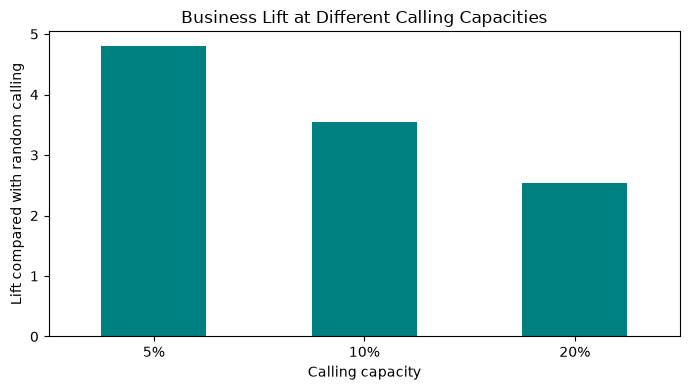

In [42]:
capacity_results.plot(
    x="Calling capacity",
    y="Lift over random calling",
    kind="bar",
    legend=False,
    color="teal",
    figsize=(7, 4)
)

plt.title("Business Lift at Different Calling Capacities")
plt.ylabel("Lift compared with random calling")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
def predict_customer(customer):
    customer_table = pd.DataFrame([customer])
    probability = float(
        selected_model.predict_proba(customer_table)[0, 1]
    )

    return {
        "subscription_probability": round(probability, 3),
        "threshold": round(float(best_threshold), 3),
        "predict_yes": bool(probability >= best_threshold)
    }


example_customer = {
    "age": 35,
    "job": "technician",
    "marital": "single",
    "education": "tertiary",
    "default": "no",
    "balance": 1500,
    "housing": "yes",
    "loan": "no",
    "pdays": -1,
    "previous": 0,
    "poutcome": "unknown"
}

result = predict_customer(example_customer)

print("Estimated chance of YES:", f"{result['subscription_probability']:.1%}")
print("YES cutoff:", f"{result['threshold']:.0%}")
print("Prediction:", "YES" if result["predict_yes"] else "NO")

Estimated chance of YES: 9.1%
YES cutoff: 20%
Prediction: NO


In [44]:

import ipywidgets as widgets
from IPython.display import display

number_defaults = {
    "age": 35,
    "balance": 1500,
    "pdays": -1,
    "previous": 0
}

fields = {}

for column, starting_value in number_defaults.items():
    fields[column] = widgets.IntText(
        value=starting_value,
        description=column,
        style={"description_width": "140px"},
        layout=widgets.Layout(width="360px")
    )

for column in CATEGORICAL_FEATURES:
    choices = sorted(X_train[column].dropna().astype(str).unique().tolist())
    fields[column] = widgets.Dropdown(
        options=choices,
        description=column,
        style={"description_width": "140px"},
        layout=widgets.Layout(width="360px")
    )

predict_button = widgets.Button(
    description="Predict",
    button_style="primary"
)
answer_box = widgets.Output()

def show_prediction(_):
    customer = {
        column: fields[column].value
        for column in FEATURES
    }

    result = predict_customer(customer)

    with answer_box:
        answer_box.clear_output(wait=True)
        print("Chance of subscribing:",
              f"{result['subscription_probability']:.1%}")
        print("YES cutoff:", f"{result['threshold']:.0%}")
        print("Prediction:",
              "YES" if result["predict_yes"] else "NO")

predict_button.on_click(show_prediction)

display(widgets.VBox(
    [fields[column] for column in FEATURES]
    + [predict_button, answer_box]
))